In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import tensorflow as tf

# Data parameters
data_dir = 'Rice_Image_Dataset'
batch_size = 256
img_height = 224
img_width = 224
total_images = 75000

# Load the full dataset
full_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    shuffle=True,
    seed=0,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Save the class names before any splitting/transformations
class_names = full_ds.class_names

# Calculate counts for splits
train_count = int(0.8 * total_images)   # 60,000 images
val_count   = int(0.1 * total_images)     # 7,500 images
# Remaining images (7,500) for testing

# Number of batches (approximate)
train_batches = train_count // batch_size
val_batches   = val_count // batch_size

# Split the dataset
train_ds = full_ds.take(train_batches)
remaining_ds = full_ds.skip(train_batches)
val_ds = remaining_ds.take(val_batches)
test_ds = remaining_ds.skip(val_batches)

# Optimize datasets with caching to disk and prefetching
# AUTOTUNE = tf.data.AUTOTUNE
# train_ds = train_ds.cache("train_cache.tf-data").prefetch(buffer_size=AUTOTUNE)
# val_ds   = val_ds.cache("val_cache.tf-data").prefetch(buffer_size=AUTOTUNE)
# test_ds  = test_ds.cache("test_cache.tf-data").prefetch(buffer_size=AUTOTUNE)

# Now your dataset pipeline should be more memory efficient.


Found 75000 files belonging to 5 classes.


2025-03-10 19:42:53.434221: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2025-03-10 19:42:53.434394: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-03-10 19:42:53.434402: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-03-10 19:42:53.434461: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-03-10 19:42:53.434626: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## Visualize the Data

2025-03-10 19:42:53.818016: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [75000]
	 [[{{node Placeholder/_4}}]]
2025-03-10 19:42:53.818189: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [75000]
	 [[{{node Placeholder/_4}}]]
2025-03-10 19:42:53.841453: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


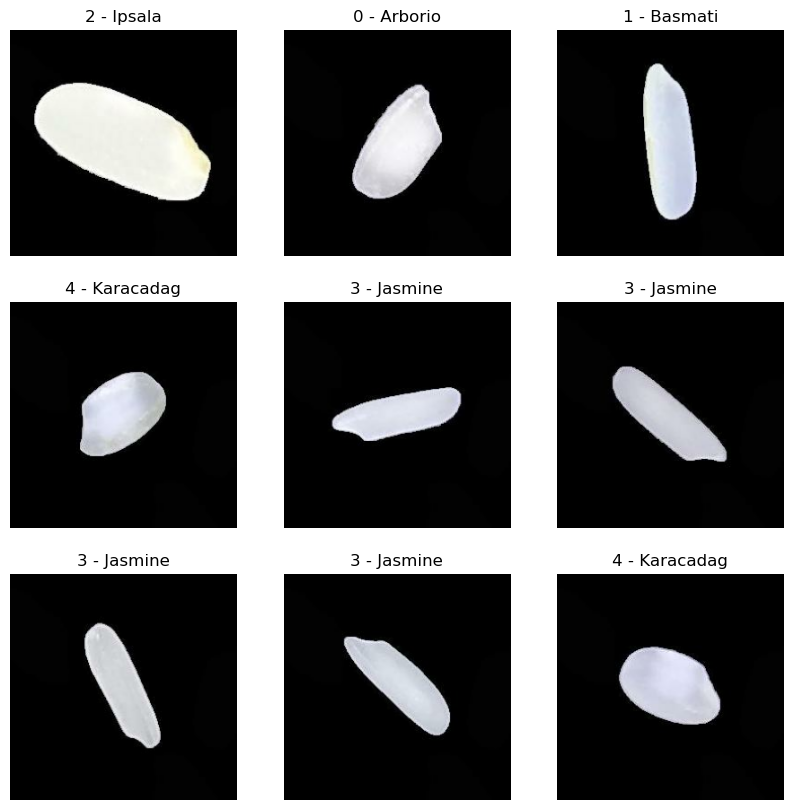

In [2]:
import matplotlib.pyplot as plt

# Display a grid of images from the training dataset
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        # Display the label number and corresponding class name (e.g., "0 - Arborio")
        label_val = labels[i].numpy()
        plt.title(f"{label_val} - {class_names[label_val]}")
        plt.axis("off")
plt.savefig('training_images.jpg', format='jpg', dpi=300)
plt.show()

# Models

## Transfer Learning Model

In [3]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

# Transfer Learning Model: Using a pre-trained MobileNetV2 as an example
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze the base model

# Add a classification head on top
global_avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
output = tf.keras.layers.Dense(5, activation='softmax')(global_avg)  # 5 classes for rice varieties

model = tf.keras.Model(inputs=base_model.input, outputs=output)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Set up EarlyStopping callback to monitor validation loss and stop training if it doesn't improve
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model using training and validation sets, with early stopping included
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,  # Adjust as needed
    callbacks=[early_stop]
)

# Print the model summary for a quick review of the architecture
model.summary()

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy:.4f}")


Epoch 1/10


2025-03-10 19:42:55.489051: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [75000]
	 [[{{node Placeholder/_0}}]]
2025-03-10 19:42:55.489215: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [75000]
	 [[{{node Placeholder/_4}}]]
2025-03-10 19:42:56.210318: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


 10/234 [>.............................] - ETA: 2:51 - loss: 1.7843 - accuracy: 0.3113

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.savefig('transfer_learning_accuracy.jpg', format='jpg', dpi=300)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get a batch from the validation dataset
for images, labels in val_ds.take(1):
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"True: {labels[i].numpy()}, Pred: {predicted_labels[i]}")
        plt.axis("off")
    plt.savefig('transfer_learning_results.jpg', format='jpg', dpi=300)
    plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Collect all predictions and true labels from the validation set
all_preds = []
all_labels = []
for images, labels in test_ds:
    preds = model.predict(images)
    all_preds.extend(np.argmax(preds, axis=1))
    all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Test Data Confusion Matrix")
plt.savefig('transfer_learning_matrix.jpg', format='jpg', dpi=300)
plt.show()


## Improved Transfer Learning Model

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

# Hyperparameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
INITIAL_EPOCHS = 5   # Train the head for a few epochs
FINE_TUNE_EPOCHS = 5 # Additional epochs for fine-tuning
FINE_TUNE_AT = 100   # Unfreeze from this layer onward

# 1. Create the base model from a pre-trained MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze all layers in the base model for initial training
base_model.trainable = False

# 2. Add a custom classification head
x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)  
output = layers.Dense(5, activation='softmax')(x)  # 5 classes

model = Model(inputs=base_model.input, outputs=output)

# Compile for initial training
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Optional EarlyStopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 3. Train only the top layers (feature extraction phase)
history_initial = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    callbacks=[early_stop]
)

# 4. Fine-tune: unfreeze some or all layers in the base model
# Example: unfreeze everything after layer index FINE_TUNE_AT
base_model.trainable = True
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

# Compile again with a lower learning rate for fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # Lower LR
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Continue training (fine-tuning phase)
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=[early_stop]
)

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy:.4f}")


In [ ]:
import matplotlib.pyplot as plt

# Number of epochs from initial and fine-tuning phases
initial_epochs = len(history_initial.history['accuracy'])
fine_epochs = len(history_fine.history['accuracy'])
total_epochs = initial_epochs + fine_epochs

# Combine the metrics from both training phases
acc = history_initial.history['accuracy'] + history_fine.history['accuracy']
val_acc = history_initial.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history_initial.history['loss'] + history_fine.history['loss']
val_loss = history_initial.history['val_loss'] + history_fine.history['val_loss']

epochs_range = range(total_epochs)

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
# Mark the point where fine-tuning started
plt.axvline(x=initial_epochs - 1, color='r', linestyle='--', label='Start Fine-Tuning')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
# Mark the fine-tuning start
plt.axvline(x=initial_epochs - 1, color='r', linestyle='--', label='Start Fine-Tuning')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.savefig('transfer_learning_improved_accuracy.jpg', format='jpg', dpi=300)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get a batch from the validation dataset
for images, labels in val_ds.take(1):
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"True: {labels[i].numpy()}, Pred: {predicted_labels[i]}")
        plt.axis("off")
    plt.savefig('transfer_learning_improved_results.jpg', format='jpg', dpi=300)
    plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Collect all predictions and true labels from the validation set
all_preds = []
all_labels = []
for images, labels in test_ds:
    preds = model.predict(images)
    all_preds.extend(np.argmax(preds, axis=1))
    all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Test Data Confusion Matrix")
plt.savefig('transfer_learning_improved_matrix.jpg', format='jpg', dpi=300)
plt.show()


## CNN Base Model

In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Rescaling, Conv2D, BatchNormalization, Activation, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Define image dimensions and batch size
img_height = 224
img_width = 224
batch_size = 256

# Build a simpler CNN model
model = Sequential([
    # Normalize pixel values to [0, 1]
    Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    
    # Convolutional Block 1
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    # Convolutional Block 2
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    # Global Average Pooling to reduce parameters and avoid flattening huge feature maps
    GlobalAveragePooling2D(),
    
    # Classification head
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')  # 5 output classes
])

# Compile the model with a standard learning rate
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# EarlyStopping callback to help avoid overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model using training and validation datasets
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

# Print the model summary for a quick review
model.summary()

# Evaluate on the test dataset
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy:.4f}")


Epoch 1/10


2025-03-10 21:36:56.118717: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


234/234 [==============================] - ETA: 0s - loss: 0.5256 - accuracy: 0.8241

2025-03-10 21:41:11.847747: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


234/234 [==============================] - 270s 1s/step - loss: 0.5256 - accuracy: 0.8241 - val_loss: 5.4030 - val_accuracy: 0.1987
Epoch 2/10
234/234 [==============================] - 267s 1s/step - loss: 0.1417 - accuracy: 0.9600 - val_loss: 5.6659 - val_accuracy: 0.3983
Epoch 3/10
234/234 [==============================] - 268s 1s/step - loss: 0.0891 - accuracy: 0.9747 - val_loss: 4.7753 - val_accuracy: 0.4359
Epoch 4/10
234/234 [==============================] - 268s 1s/step - loss: 0.0627 - accuracy: 0.9825 - val_loss: 7.5218 - val_accuracy: 0.4002
Epoch 5/10
234/234 [==============================] - 268s 1s/step - loss: 0.0536 - accuracy: 0.9851 - val_loss: 7.2971 - val_accuracy: 0.3935
Epoch 6/10
234/234 [==============================] - 270s 1s/step - loss: 0.0421 - accuracy: 0.9877 - val_loss: 3.7359 - val_accuracy: 0.4853
Epoch 7/10
234/234 [==============================] - ETA: 0s - loss: 0.0382 - accuracy: 0.9891

KeyboardInterrupt: 

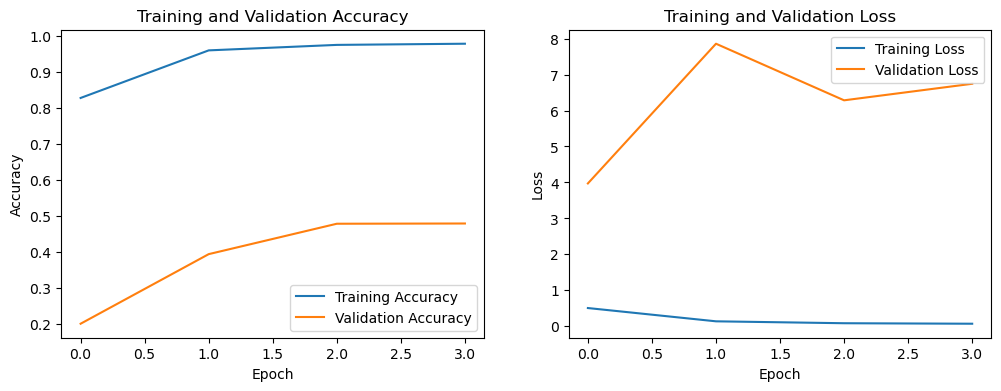

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.savefig('cnn_accuracy.jpg', format='jpg', dpi=300)
plt.show()


2025-03-10 21:35:05.278378: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [75000]
	 [[{{node Placeholder/_4}}]]
2025-03-10 21:35:05.278624: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [75000]
	 [[{{node Placeholder/_0}}]]


7/8 [=========================>....] - ETA: 0s

2025-03-10 21:35:12.362783: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


8/8 [==============================] - 0s 22ms/step


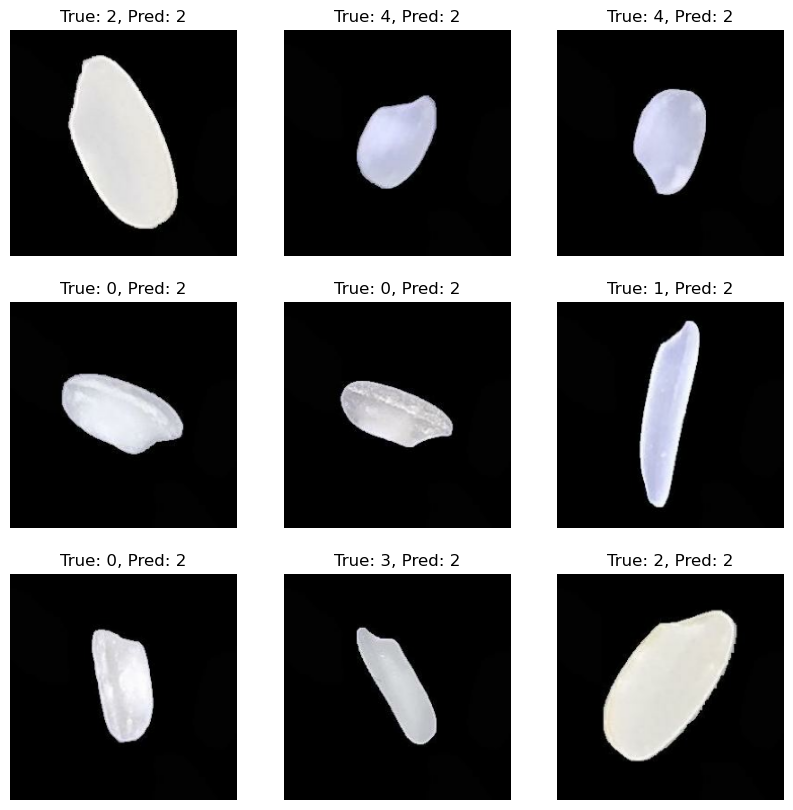

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get a batch from the validation dataset
for images, labels in val_ds.take(1):
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"True: {labels[i].numpy()}, Pred: {predicted_labels[i]}")
        plt.axis("off")
    plt.savefig('cnn_results.jpg', format='jpg', dpi=300)
    plt.show()


8/8 [==============================] - 0s 23ms/step


2025-03-10 21:35:29.339810: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


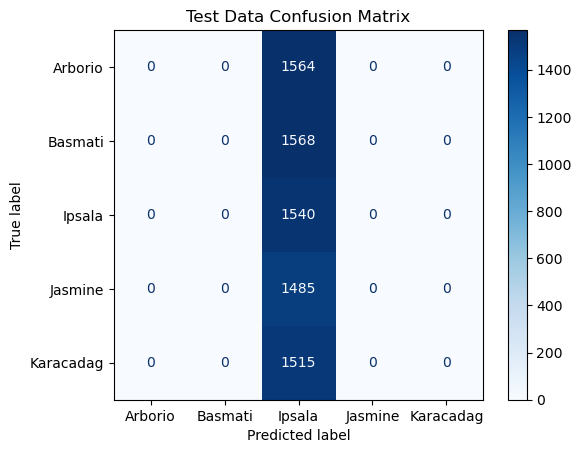

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Collect all predictions and true labels from the validation set
all_preds = []
all_labels = []
for images, labels in test_ds:
    preds = model.predict(images)
    all_preds.extend(np.argmax(preds, axis=1))
    all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Test Data Confusion Matrix")
plt.savefig('cnn_matrix.jpg', format='jpg', dpi=300)
plt.show()


## Improved CNN Model

In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout

# Define image dimensions and batch size
img_height = 224
img_width = 224
batch_size = 256

# Build an improved CNN model
model = Sequential([
    InputLayer(input_shape=(img_height, img_width, 3)),
    
    # Convolutional Block 1
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    
    # Convolutional Block 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    
    # Convolutional Block 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    
    # Global Average Pooling reduces the spatial dimensions to 1
    GlobalAveragePooling2D(),
    
    # A smaller dense layer for classification
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')  # 5 output classes for your rice varieties
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Set up EarlyStopping to avoid overfitting
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model using the training and validation datasets
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,  # Adjust epochs as needed
    callbacks=[early_stop]
)

# Print the model summary for a quick review
model.summary()

# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy:.4f}")


Epoch 1/10


2025-03-10 20:22:10.690709: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


234/234 [==============================] - ETA: 0s - loss: 1.4031 - accuracy: 0.4904

2025-03-10 20:25:55.125630: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


234/234 [==============================] - 236s 1s/step - loss: 1.4031 - accuracy: 0.4904 - val_loss: 0.3047 - val_accuracy: 0.8710
Epoch 2/10
234/234 [==============================] - 238s 1s/step - loss: 0.2562 - accuracy: 0.9082 - val_loss: 0.0777 - val_accuracy: 0.9767
Epoch 3/10
234/234 [==============================] - 239s 1s/step - loss: 0.0974 - accuracy: 0.9669 - val_loss: 0.0453 - val_accuracy: 0.9830
Epoch 4/10
234/234 [==============================] - 237s 1s/step - loss: 0.1736 - accuracy: 0.9481 - val_loss: 0.0375 - val_accuracy: 0.9868
Epoch 5/10
234/234 [==============================] - 240s 1s/step - loss: 0.1121 - accuracy: 0.9628 - val_loss: 0.0255 - val_accuracy: 0.9899
Epoch 6/10
234/234 [==============================] - 242s 1s/step - loss: 0.0624 - accuracy: 0.9790 - val_loss: 0.1044 - val_accuracy: 0.9605
Epoch 7/10
234/234 [==============================] - 240s 1s/step - loss: 0.0515 - accuracy: 0.9832 - val_loss: 0.0180 - val_accuracy: 0.9941
Epoch 8/10

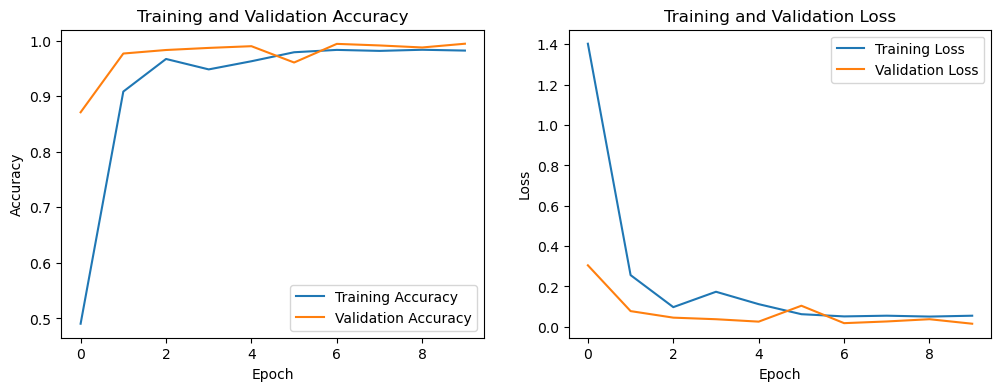

In [13]:
# Assuming `history` is the output from model.fit
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.savefig('cnn_improved_accuracy.jpg', format='jpg', dpi=300)
plt.show()


2025-03-10 21:02:10.421069: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [75000]
	 [[{{node Placeholder/_0}}]]
2025-03-10 21:02:10.421412: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [75000]
	 [[{{node Placeholder/_4}}]]


8/8 [==============================] - 0s 18ms/step


2025-03-10 21:02:18.357221: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


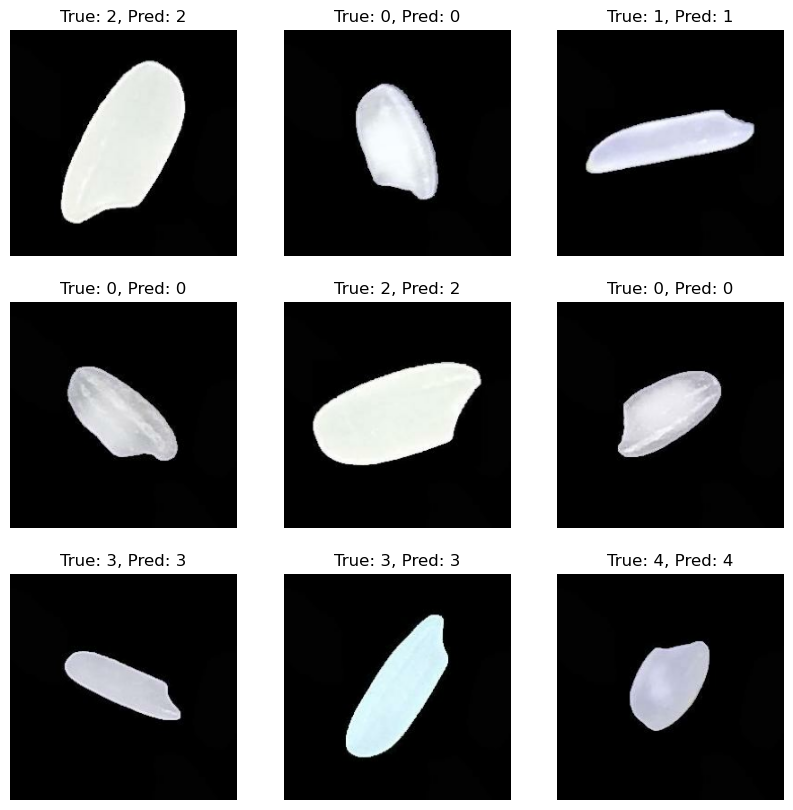

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Get a batch from the validation dataset
for images, labels in val_ds.take(1):
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"True: {labels[i].numpy()}, Pred: {predicted_labels[i]}")
        plt.axis("off")
    plt.savefig('cnn_improved_results.jpg', format='jpg', dpi=300)
    plt.show()


8/8 [==============================] - 0s 24ms/step


2025-03-10 21:02:33.817840: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


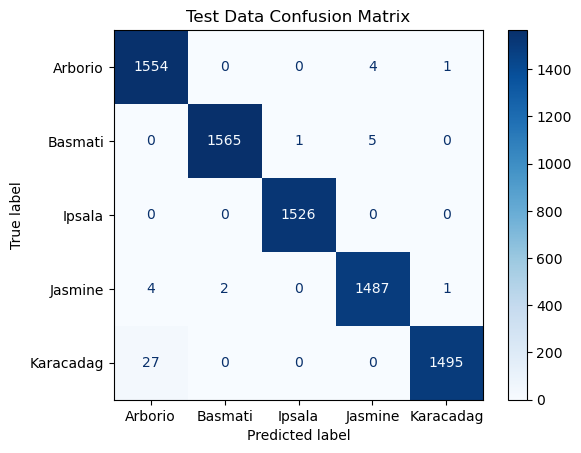

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Collect all predictions and true labels from the validation set
all_preds = []
all_labels = []
for images, labels in test_ds:
    preds = model.predict(images)
    all_preds.extend(np.argmax(preds, axis=1))
    all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Test Data Confusion Matrix")
plt.savefig('cnn_imporved_matrix.jpg', format='jpg', dpi=300)
plt.show()


## Potential Next Steps

1. **Targeted Data Augmentation**  
   - **Class-Specific Augmentation:** If Karacadag and Arborio are often confused, try augmenting those classes more aggressively (e.g., brightness, contrast, rotations).  
   - **Focus on Distinguishing Features:** If grain shape or color is key, consider augmentations that preserve or highlight those differences (e.g., zooming in).

2. **Collect More Examples**  
   - If possible, gather additional or higher-resolution images specifically for the confusing pairs (Arborio vs. Karacadag, Basmati vs. Jasmine). More diverse images can help the model learn finer distinctions.

3. **Fine-Tuning the Transfer Learning Model**  
   - If you want the transfer learning model to catch up to or surpass the CNN’s performance, unfreeze more layers in the pre-trained network and train at a lower learning rate. This sometimes helps the model learn domain-specific details.

4. **Experiment with Other Architectures**  
   - Try different backbones (e.g., EfficientNet, ResNet) or experiment with a deeper custom CNN. Sometimes a slightly more complex architecture can capture subtle class differences better.

5. **Feature Engineering (If Applicable)**  
   - If you have the option to measure grain length or other morphological features (outside pure image data), combining them with the CNN’s predictions can help disambiguate visually similar varieties.